In [16]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
sns.set_theme()

In [27]:
strategy = "0a"
folder = "DeltaIoT_modelled_ea_strategy%s" % strategy
filename = "%s_cumulative_pareto_fronts.csv" % folder
filename_pdf = "%s_cumulative_pareto_fronts.pdf" % folder
filename_png = "%s_cumulative_pareto_fronts.png" % folder

In [28]:
simexp_path = Path.cwd().parent / "simulation_result"

In [29]:
#df = pd.read_csv(simexp_path / "resources" / "DeltaIoT_modelled_ea_strategy" + strategy / "DeltaIoT_modelled_ea_strategy" + strategy + "_cumulative_pareto_fronts.csv")
df = pd.read_csv(simexp_path / "resources" / folder / filename)

In [30]:
#df.head()

In [31]:
generations = df["generation"].drop_duplicates()
#print("generations: %s" % generations)
selected_generations = sorted(
    set(list(generations.head(1)) + list(generations.tail(2)) + list(generations.iloc[::7]))
)
print("selected: %s" % selected_generations)
df_reduced = df[df["generation"].isin(selected_generations)]
final_generation = selected_generations[-1]
approx_generation = -1

selected: [1, 7, 8]


In [32]:
#df_reduced.tail()

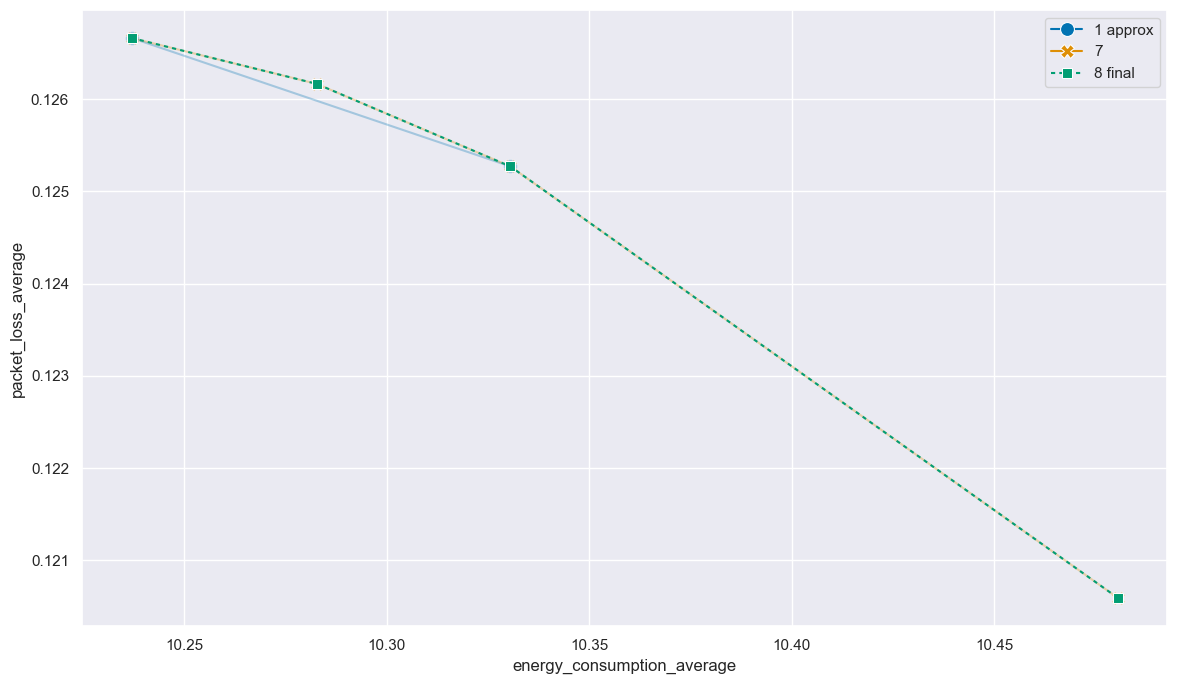

In [33]:
dashes_dict = {gen: () for gen in df_reduced["generation"].unique()}
dashes_dict[-1] = (4, 2)  # 3 points line, 2 points space = dashed
dashes_dict[final_generation] = (2, 2)  # 3 points line, 3 points space = dashed

plt.figure(figsize=(14, 8))
ax = sns.lineplot(data=df_reduced,
             x="energy_consumption_average", y="packet_loss_average",
             hue="generation", style="generation",
             markers=True,
             markersize=10,
             #dashes=False,
             dashes=dashes_dict,
             legend="full",
             palette="colorblind",
             #alpha=1,
            )
handles, labels = ax.get_legend_handles_labels()
final_label = str(final_generation)
approx_label = str(-1)
for line, label in zip(ax.lines, labels):
    if label == approx_label:
        line.set_alpha(1.0)   # fully opaque
        #line.set_linewidth(3)
    elif label == final_label:
        line.set_alpha(1.0)   # fully opaque
    else:
        line.set_alpha(0.3)   # others semi-transparent
labels[0] = labels[0] + " approx"
labels[-1] = labels[-1] + " final"
ax.legend(handles, labels)
plt.savefig(simexp_path / "resources" / folder / filename_png, dpi=300, bbox_inches="tight")
plt.savefig(simexp_path / "resources" / folder / filename_pdf, dpi=300, bbox_inches="tight")
plt.show()